In [1]:
import numpy as np
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score,precision_score,recall_score,f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder

import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from spacy.lang.en.stop_words import STOP_WORDS as en_stop
from nltk import word_tokenize          

from gensim.models import Word2Vec

In [2]:


class GenreClassifier(nn.Module):
    def __init__(self, input_dim,hidden_dim, num_classes=6):
        super(GenreClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes) 
        self.relu = nn.ReLU()  

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x
    


class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        """
        patience: Nombre d'époques à attendre avant d'arrêter si pas d'amélioration.
        min_delta: Amélioration minimale considérée comme significative.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0 
        else:
            self.counter += 1 
        return self.counter >= self.patience


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
def train(dataloader,model,loss_fnc,optimizer,epoch):
    model.train()
    for batch_size,(X,y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = loss_fnc(y_pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(f"Step: {epoch} Train Loss: {loss.item():.4f}")
    return loss


def test(dataloader,model,loss_fnc,encoder):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        X_test = torch.cat([X for X, _ in dataloader], dim=0)
        y_test = torch.cat([y for _, y in dataloader], dim=0)
        X_test = X_test.to(device)
        y_test = y_test.to(device)
        y_pred = model(X_test)
        test_loss += loss_fnc(y_pred, y_test).item()

    y_test = y_test.cpu().numpy()
    y_pred = torch.argmax(y_pred, dim=1).cpu().numpy()

    print(f"Classification Report:\n", classification_report(encoder.inverse_transform(y_test), encoder.inverse_transform(y_pred)))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


# Processing data

In [5]:
# Variable
percentage_genre_to_keep = 25
test_size = 0.2
random_state = 42

In [6]:
df = pd.read_csv("../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['Script','filtered_genre']

df_movies = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_movies = df_movies[columns_to_keep].reset_index(drop=True)


C:\Users\letru\AppData\Local\Temp\ipykernel_1532\2146986483.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


# Training and test

In [7]:
X_train,X_test , y_train,y_test = train_test_split(df_movies['Script'],df_movies['filtered_genre'],test_size=test_size,random_state=random_state)

In [8]:
X_train_token = [word_tokenize(script) for script in X_train]
X_test_token = [word_tokenize(script) for script in X_test]

In [9]:
word2vec = Word2Vec(sentences=X_train_token, vector_size=300, window=5, min_count=2, workers=4)

In [19]:
def vectorize_sentence(sentence, model):
    """Retourne la moyenne des vecteurs des mots d'une phrase"""
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)


X_train_vectors = np.array([vectorize_sentence(sent, word2vec) for sent in X_train_token])
X_test_vectors = np.array([vectorize_sentence(sent, word2vec) for sent in X_test_token])

In [20]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

X_tensor_train = torch.tensor(X_train_vectors,dtype=torch.float32)
X_tensor_test = torch.tensor(X_test_vectors,dtype=torch.float32)
y_tensor_train = torch.tensor(y_train_encoded,dtype=torch.long).view(-1)
y_tensor_test = torch.tensor(y_test_encoded,dtype=torch.long).view(-1)



In [23]:
dataset_train = TensorDataset(X_tensor_train,y_tensor_train)
dataset_test = TensorDataset(X_tensor_test,y_tensor_test)
dataloader_train = DataLoader(dataset_train,batch_size=50)
dataloader_test = DataLoader(dataset_test,batch_size=50)

In [26]:
model = GenreClassifier(X_train_vectors.shape[1],hidden_dim=128).to(device)
early_stopping = EarlyStopping(patience=50, min_delta=0.0001)
loss_fnc = nn.CrossEntropyLoss()
optimizer_adam = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 2000
for epoch in range(epochs):
    loss = train(dataloader_train,model,loss_fnc,optimizer_adam,epoch)
    if early_stopping(loss):
        print(f"Early stopping triggered at epoch {epoch} ")
        break



Step: 0 Train Loss: 0.9390
Step: 100 Train Loss: 0.4846
Step: 200 Train Loss: 0.4442
Step: 300 Train Loss: 0.4113
Step: 400 Train Loss: 0.3936
Step: 500 Train Loss: 0.3900
Early stopping triggered at epoch 529 


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.73      0.77      0.75       314
imdb_documentary       0.93      0.87      0.90       251
      imdb_drama       0.71      0.86      0.78       609
     imdb_horror       0.87      0.67      0.75       171
    imdb_romance       0.91      0.33      0.48        61
   imdb_thriller       0.69      0.38      0.49       138

        accuracy                           0.76      1544
       macro avg       0.80      0.65      0.69      1544
    weighted avg       0.77      0.76      0.75      1544



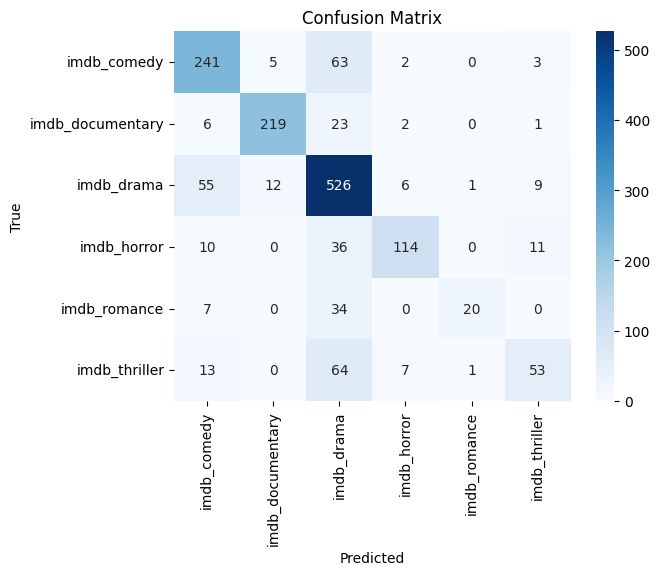

In [37]:
test(dataloader_test,model,loss_fnc,encoder)

# Data augmentation